<a href="https://colab.research.google.com/github/Lightrex7749/AI-ML-DL/blob/main/cse471.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Computer Vision with Pre-trained Models

This notebook demonstrates a simple image classification task using a pre-trained AlexNet model from `torchvision`. It covers loading the model, fetching an image, performing inference, and displaying the results. Subsequently, it sets up for training a neural network on the MNIST dataset, including data loading and preprocessing.

### 1. Library Imports for Image Classification

This section imports all necessary libraries for loading a pre-trained model, handling images, performing numerical operations, and visualizing results.

In [2]:
import torch
from torchvision import models
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import requests
from io import BytesIO
import torchvision.transforms as T

### 2. Load Pre-trained AlexNet Model

Here, we load the AlexNet model with its default pre-trained weights. The model is then set to evaluation mode, which disables dropout and batch normalization updates, making it suitable for inference.

In [3]:
weight =models.AlexNet_Weights.DEFAULT
model=models.alexnet(weights=weight)
model.eval()
print("Dine")

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:02<00:00, 89.1MB/s]


Dine


### 3. Fetch and Display Input Image

This cell retrieves an image from a specified URL, converts it to a standard RGB format, and displays it. This image will be used as input for the AlexNet model.

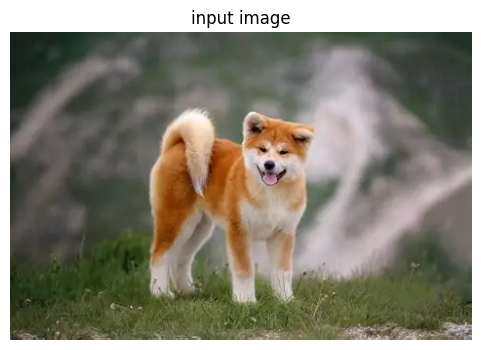

In [4]:
url="https://tse2.mm.bing.net/th/id/OIP.YezLnuZJ3NiM-Iu3Dka20gHaE8?r=0&rs=1&pid=ImgDetMain&o=7&rm=3"
response=requests.get(url)
image=Image.open(BytesIO(response.content)).convert('RGB')
plt.figure(figsize=(6,4))
plt.imshow(image)
plt.axis('off')
plt.title("input image")
plt.show()

### 4. Image Preprocessing and Model Inference

The loaded image is preprocessed according to the requirements of the pre-trained AlexNet model. The model then performs inference to predict the image's class, and the raw output probabilities are processed to find the most confident prediction.

In [5]:
preprocess = weight.transforms()
input_batch = preprocess(image).unsqueeze(0)

with torch.no_grad():
  output = model(input_batch)
  probabilities = torch.nn.functional.softmax(output[0], dim=0)
  confidence, class_id = torch.max(probabilities, dim=0)
  predicted_class = weight.meta['categories'][class_id]
  print('predicted', predicted_class)
  print(f'confidence:- {confidence.item()*100:.2f}')

predicted papillon
confidence:- 44.14


### 5. Analyze Top Predictions

This section identifies and displays the top 5 most likely classes predicted by the model, along with their respective confidence scores, providing a more detailed understanding of the model's output.

In [6]:
top5_prob,top5_indices=torch.topk(probabilities,5)
print("top-5")
print("-" * 45)
for i in range(5):
  class_name=weight.meta['categories'][top5_indices[i]]
  probability=top5_prob[i].item()*100
  print(f'{i+1}:-class {class_name}:{probability:.2f}%')

top-5
---------------------------------------------
1:-class papillon:44.14%
2:-class Pembroke:21.22%
3:-class Japanese spaniel:11.96%
4:-class borzoi:4.57%
5:-class chow:3.85%


### 6. Visualize Prediction Results

The input image is displayed again, this time with the model's most confident prediction and its confidence score annotated on the title, offering a direct visual feedback of the classification result.

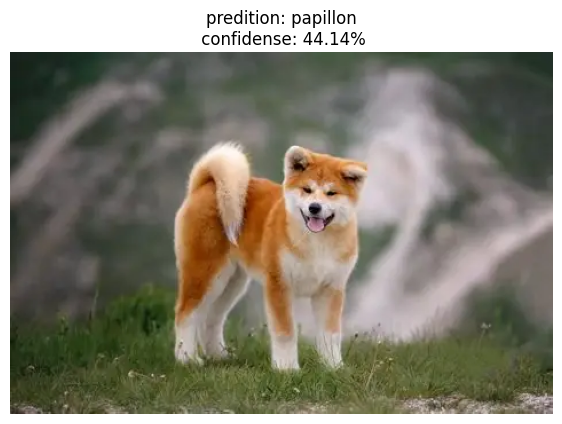

In [7]:
plt.figure(figsize=(7,5))
plt.imshow(image)
plt.axis("off")
plt.title(f"predition: {predicted_class}\n confidense: {confidence.item()*100:.2f}%")
plt.show()

### 7. MNIST Dataset Setup - Library Imports

This section imports essential libraries required for setting up, training, and evaluating a neural network on the MNIST dataset, including PyTorch modules for neural networks, optimization, and data handling.

In [8]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets,transforms

### 8. Configuration and Environment Setup

This cell sets random seeds for reproducibility, configures the execution device (GPU if available, otherwise CPU), and applies aesthetic settings for `matplotlib` plots.

In [9]:


# Set random seed for perfect reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Detect GPU / MPS / CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🚀 Execution Device: {device}')
if torch.cuda.is_available():
  print(f'GPU: {torch.cuda.get_device_name(0)}')

# Matplotlib styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

🚀 Execution Device: cuda
GPU: Tesla T4


### 9. MNIST Dataset Loading and DataLoaders

Here, data transformations are defined for preprocessing the MNIST images. The MNIST training and test datasets are then loaded and encapsulated into `DataLoader` objects, which handle batching and shuffling for efficient model training and evaluation.

In [10]:
transform=transforms.Compose([
  transforms.ToTensor(),
  transforms.Normalize((0.1307,),(0.381,1)),
])

train_dataset=datasets.MNIST(root='./data',train=True,download=True,transform=transform)
test_dataset=datasets.MNIST(root='./data',train=False,download=True,transform=transform)
Batch_size=128
train_loader=DataLoader(train_dataset,batch_size=Batch_size,shuffle=True,num_workers=0)
test_loader=DataLoader(test_dataset,batch_size=Batch_size,shuffle=False,num_workers=0)

print(f"Dataset Loaded")
print(f'  - Traning Samples: {len(train_dataset):,} {len(train_loader)} batcahes size {Batch_size}')

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.90MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 129kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.20MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.1MB/s]

Dataset Loaded
  - Traning Samples: 60,000 469 batcahes size 128


✅ MNIST Dataset Loaded:
 - Training Smaples: 60,000 (469 batches of size 128)
 - Test Smaples: 10,000 (79 batches of size 128)


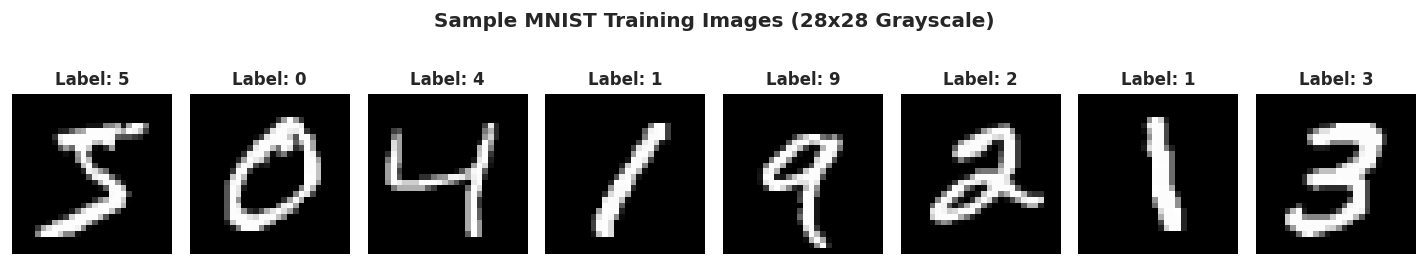

In [11]:
# Data Tranformation pipeline
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081, ))
])

# Downlaod MNIST train and test sets
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f'✅ MNIST Dataset Loaded:')
print(f' - Training Smaples: {len(train_dataset):,} ({len(train_loader)} batches of size {batch_size})')
print(f' - Test Smaples: {len(test_dataset):,} ({len(test_loader)} batches of size {batch_size})')

# Visualize sample digits
fig, axes = plt.subplots(1, 8, figsize=(12, 2.5))
for i in range(8):
  img, lbl = train_dataset[i]
  axes[i].imshow(img.squeeze(), cmap='gray')
  axes[i].set_title(f'Label: {lbl}', fontsize = 10, fontweight = 'bold')
  axes[i].axis('off')
plt.suptitle('Sample MNIST Training Images (28x28 Grayscale)', fontsize = 12, fontweight = 'bold')
plt.tight_layout()
plt.show()

In [13]:
class LeNet5(nn.Module):
  def __init__(self, num_classes = 10):
    super(LeNet5, self).__init__()
    self.feature_extractor = nn.Sequential(
        # C1 : 1 in_channel -> 6 out_channels, 5x5 kernel, padding = 2 to keep 28x28
        nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1, padding = 2),
        nn.ReLU(),
        #S2 : Max Pooling 2x2, stride = 2 -> Output 6x14x14
        nn.MaxPool2d(kernel_size = 2, stride = 2),

        #C3 : 6 in_channels -> 16 out_channels, 5x5 kernel, padding = 0 -> Output 16x10x10
        nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1, padding = 0),
        nn.ReLU(),
        #S4 : Max Pooling 2x2, stride = 2 -> Output 16x5x5
        nn.MaxPool2d(kernel_size = 2, stride = 2)
    )